In [29]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from pathlib import Path

from outofplane import isOutOfPlane



In [30]:
def generate_webgazer_dataframe(df):
    df1 = df[df["trial_type"] == "html-button-response"]
    df_webgazer = df1[~df1["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [31]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "rotation" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/rotation-experiment-11.csv
1054
data/rotation-experiment-10.csv
1175
data/rotation-experiment-12.csv
2116
data/rotation-experiment-13.csv
1057
data/rotation-experiment-14.csv
1169
data/rotation-experiment-15.csv
1335
data/rotation-experiment-9.csv
941
data/rotation-experiment-8.csv
1757
data/rotation-experiment-5.csv
1081
data/rotation-experiment-6.csv
874
data/rotation-experiment-7.csv
1114
13673


In [32]:
df_webgazer["isRotated"] = df_webgazer["importantKeypoints"].map(
    lambda x: isOutOfPlane(x)
)

# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,isRotated
0,0,0,6,"{'noseX': 328.62, 'noseY': 252, 'topY': 155.61...",62.64,1,0,data/rotation-experiment-11.csv,"[False, False, False, False, False, False, Fal..."
1,0,0,56,"{'noseX': 327.77, 'noseY': 252.3, 'topY': 155....",62.54,1,0,data/rotation-experiment-11.csv,"[False, False, False, False, False, False, Fal..."
2,0,0,83,"{'noseX': 327.61, 'noseY': 251.42, 'topY': 154...",63.43,1,0,data/rotation-experiment-11.csv,"[False, False, False, False, False, False, Fal..."
3,0,0,108,"{'noseX': 327.34, 'noseY': 251.69, 'topY': 154...",64.50,1,0,data/rotation-experiment-11.csv,"[False, False, False, False, False, False, Fal..."
4,0,0,143,"{'noseX': 328.31, 'noseY': 250.94, 'topY': 154...",60.32,1,0,data/rotation-experiment-11.csv,"[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...,...
118,0,0,4016,"{'noseX': 333.76, 'noseY': 337.38, 'topY': 196...",39.75,8,10,data/rotation-experiment-7.csv,"[False, False, False, False, True, True, True,..."
119,0,0,4049,"{'noseX': 333.74, 'noseY': 336.54, 'topY': 195...",39.38,8,10,data/rotation-experiment-7.csv,"[False, False, False, False, True, True, True,..."
120,0,0,4083,"{'noseX': 333.7, 'noseY': 335.87, 'topY': 195....",38.53,8,10,data/rotation-experiment-7.csv,"[False, False, False, False, True, True, True,..."
121,0,0,4117,"{'noseX': 333.7, 'noseY': 335.25, 'topY': 195....",38.05,8,10,data/rotation-experiment-7.csv,"[False, False, False, False, True, True, True,..."


In [33]:
df_webgazer[df_webgazer["trial"]==9]

,x,y,t,importantKeypoints,dz,trial,experiment,file_name,isRotated


In [34]:
df_webgazer["Rotation_threshold"] = df_webgazer["isRotated"].apply(lambda x: int(x[0]==True))
df_webgazer["Rotation_threshold1"] = df_webgazer["isRotated"].apply(lambda x: int(x[1]==True))
df_webgazer["Rotation_threshold2"] = df_webgazer["isRotated"].apply(lambda x: int(x[2]==True))
df_webgazer["Rotation_threshold3"] = df_webgazer["isRotated"].apply(lambda x: int(x[3]==True))
df_webgazer["Rotation_threshold4"] = df_webgazer["isRotated"].apply(lambda x: int(x[4]==True))
df_webgazer["Rotation_threshold5"] = df_webgazer["isRotated"].apply(lambda x: int(x[5]==True))
df_webgazer["Rotation_threshold6"] = df_webgazer["isRotated"].apply(lambda x: int(x[6]==True))
df_webgazer["Rotation_threshold7"] = df_webgazer["isRotated"].apply(lambda x: int(x[7]==True))
df_webgazer["Rotation_threshold8"] = df_webgazer["isRotated"].apply(lambda x: int(x[8]==True))

In [35]:
df_webgazer["Rotation_threshold0_diff"] = (df_webgazer['Rotation_threshold'].shift(1)+1 == df_webgazer['Rotation_threshold'])
df_webgazer["Rotation_threshold1_diff"] = (df_webgazer['Rotation_threshold1'].shift(1)+1 == df_webgazer['Rotation_threshold1'])
df_webgazer["Rotation_threshold2_diff"] = (df_webgazer['Rotation_threshold2'].shift(1)+1 == df_webgazer['Rotation_threshold2'])
df_webgazer["Rotation_threshold3_diff"] = (df_webgazer['Rotation_threshold3'].shift(1)+1 == df_webgazer['Rotation_threshold3'])
df_webgazer["Rotation_threshold4_diff"] = (df_webgazer['Rotation_threshold4'].shift(1)+1 == df_webgazer['Rotation_threshold4'])
df_webgazer["Rotation_threshold5_diff"] = (df_webgazer['Rotation_threshold5'].shift(1)+1 == df_webgazer['Rotation_threshold5'])
df_webgazer["Rotation_threshold6_diff"] = (df_webgazer['Rotation_threshold6'].shift(1)+1 == df_webgazer['Rotation_threshold6'])
df_webgazer["Rotation_threshold7_diff"] = (df_webgazer['Rotation_threshold7'].shift(1)+1 == df_webgazer['Rotation_threshold7'])
df_webgazer["Rotation_threshold8_diff"] = (df_webgazer['Rotation_threshold8'].shift(1)+1 == df_webgazer['Rotation_threshold8'])

results = []
for x in range(0,9):
    tmp_result = df_webgazer.groupby(['trial', 'file_name'])['Rotation_threshold' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

cleaned_results = [results[0]] + [df.drop(columns=['trial', 'file_name']) for df in results[1:]]
result = pd.concat(cleaned_results, axis=1)
result

,trial,file_name,Rotation_threshold0_diff,Rotation_threshold1_diff,Rotation_threshold2_diff,Rotation_threshold3_diff,Rotation_threshold4_diff,Rotation_threshold5_diff,Rotation_threshold6_diff,Rotation_threshold7_diff,Rotation_threshold8_diff
0,1,data/rotation-experiment-10.csv,1,1,1,1,1,3,13,1,1
1,1,data/rotation-experiment-11.csv,1,1,1,1,1,2,4,7,4
2,1,data/rotation-experiment-12.csv,4,3,3,3,3,7,4,4,12
3,1,data/rotation-experiment-13.csv,1,1,1,1,1,1,1,1,1
4,1,data/rotation-experiment-14.csv,1,1,1,1,1,1,1,10,0
...,...,...,...,...,...,...,...,...,...,...,...
83,8,data/rotation-experiment-5.csv,0,0,0,0,0,3,2,2,1
84,8,data/rotation-experiment-6.csv,0,0,1,1,0,0,0,0,0
85,8,data/rotation-experiment-7.csv,0,0,1,1,3,0,0,0,0
86,8,data/rotation-experiment-8.csv,0,0,1,1,1,1,4,2,0


In [36]:
threshold_columns = [col for col in result.columns if col not in ['trial', 'file_name']]
result['should_be'] = result['trial'].apply(lambda x: x % 2)
result[result['trial']==3]

,trial,file_name,Rotation_threshold0_diff,Rotation_threshold1_diff,Rotation_threshold2_diff,Rotation_threshold3_diff,Rotation_threshold4_diff,Rotation_threshold5_diff,Rotation_threshold6_diff,Rotation_threshold7_diff,Rotation_threshold8_diff,should_be
22,3,data/rotation-experiment-10.csv,1,1,1,1,1,1,1,2,0,1
23,3,data/rotation-experiment-11.csv,1,1,1,1,1,1,1,1,2,1
24,3,data/rotation-experiment-12.csv,1,1,3,2,2,5,8,3,13,1
25,3,data/rotation-experiment-13.csv,1,1,1,1,1,1,2,1,0,1
26,3,data/rotation-experiment-14.csv,0,0,0,0,0,0,0,12,1,1
27,3,data/rotation-experiment-15.csv,5,5,5,5,6,5,5,5,4,1
28,3,data/rotation-experiment-5.csv,1,1,1,1,2,1,3,2,2,1
29,3,data/rotation-experiment-6.csv,1,1,1,1,1,2,0,0,0,1
30,3,data/rotation-experiment-7.csv,1,1,1,1,1,1,0,0,0,1
31,3,data/rotation-experiment-8.csv,1,1,1,1,1,1,0,4,0,1


In [37]:
threshold_columns = result.columns[2:-1]
threshold_columns

Index(['Rotation_threshold0_diff', 'Rotation_threshold1_diff',
       'Rotation_threshold2_diff', 'Rotation_threshold3_diff',
       'Rotation_threshold4_diff', 'Rotation_threshold5_diff',
       'Rotation_threshold6_diff', 'Rotation_threshold7_diff',
       'Rotation_threshold8_diff'],
      dtype='object')

In [38]:
metodo = "EAR"

# Obtener las columnas de thresholds (excluyendo 'trial' y 'Should be')
threshold_columns = result.columns[2:-1]

threshold_values = [0.15, 0.25, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85]
# Resultados globales
results_global = []
for i, threshold in enumerate(threshold_columns):
    preds = result[threshold]
    truth = result['should_be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results_global.append({'Threshold': threshold_values[i], 'Error Absoluto Medio': mae, 'Error Cuadrático Medio': rmse})

results_global_df = pd.DataFrame(results_global).sort_values(by='Error Cuadrático Medio')

results_global_df


,Threshold,Error Absoluto Medio,Error Cuadrático Medio
1,0.25,0.613636,1.033529
4,0.60,0.659091,1.076611
0,0.15,0.636364,1.107823
2,0.40,0.750000,1.331438
3,0.50,0.681818,1.381699
6,0.75,1.340909,2.320854
5,0.70,1.227273,2.549510
8,0.85,2.045455,3.313197
7,0.80,2.193182,3.952847


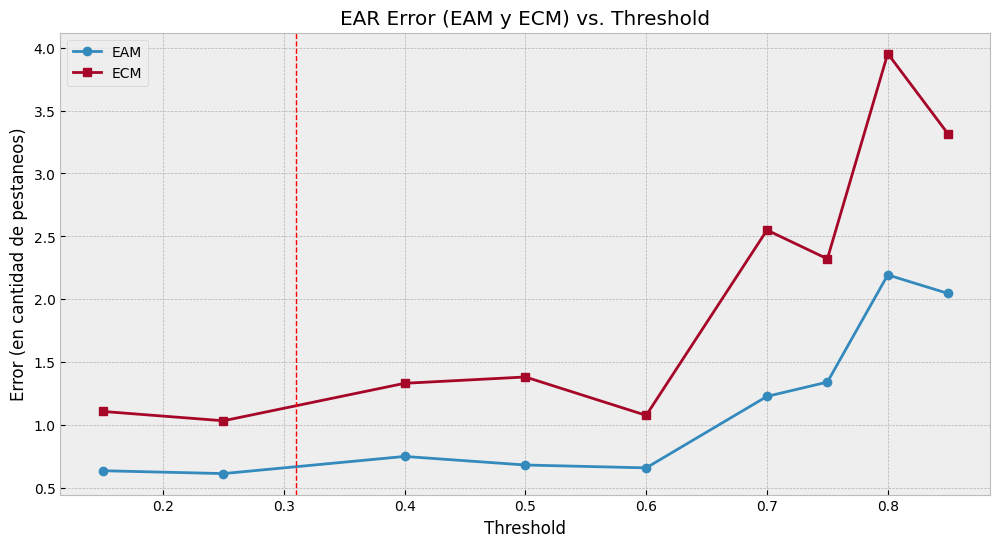

In [39]:
threshold_columns = result.columns[2:-1]
plt.style.use('bmh')
threshold_values = [0.15, 0.25, 0.4, 0.5, 0.6, 0.7, 0.75, 0.8, 0.85]

# Calcular MAE y RMSE por threshold
results = []
for i, threshold in enumerate(threshold_columns):
    preds = result[threshold]
    truth = result['should_be']
    mae = np.mean(np.abs(preds - truth))
    rmse = np.sqrt(np.mean((preds - truth) ** 2))
    results.append({
        'Threshold': threshold_values[i],
        'Threshold_float': float(str(threshold_values[i]).replace(",", ".").replace(" ", "")),
        'MAE': mae,
        'RMSE': rmse
    })

results_df = pd.DataFrame(results).sort_values('Threshold_float')

# Graficar
plt.figure(figsize=(12, 6))
plt.plot(results_df['Threshold_float'], results_df['MAE'], label='EAM', marker='o')
plt.plot(results_df['Threshold_float'], results_df['RMSE'], label='ECM', marker='s')
plt.xlabel("Threshold")
plt.ylabel("Error (en cantidad de pestaneos)")
plt.axvline(0.31, color="red", linestyle="--", lw=1)
plt.title(metodo + " Error (EAM y ECM) vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
results_df

,Threshold,Threshold_float,MAE,RMSE
0,0.15,0.15,0.810345,1.444371
1,0.25,0.25,0.844828,1.785961
2,0.40,0.40,0.956897,2.187346
3,0.50,0.50,1.129310,4.882234
4,0.60,0.60,1.698276,6.613075
5,0.70,0.70,3.818966,13.936741
6,0.75,0.75,3.241379,10.482333
7,0.80,0.80,2.956897,6.679227
8,0.85,0.85,2.120690,3.638871
